In [1]:
import numpy as np 
from sklearn import preprocessing

import os
focks = np.load("td_Fock_at_re+im_rt-tdexx_delta_s0_h2_sto-3g_PYSCF.npz")
denss = np.load("td_dens_re+im_rt-tdexx_delta_s0_h2_sto-3g_PYSCF.npz")

for f in focks.files:
    print(f, focks[f].shape, focks[f].dtype)
for f in denss.files:
    print(f, denss[f].shape, denss[f].dtype)

td_fock_at_re_data (20000, 2, 2) float64
td_fock_at__im_data (20000, 2, 2) float64
td_dens_re_data (20000, 2, 2) float64
td_dens_im_data (20000, 2, 2) float64


In [2]:
print ("Density matrix at t=0:")
print (denss['td_dens_re_data'][0,:,:])
print (denss['td_dens_re_data'][0,:,:].flatten())
print (denss['td_dens_im_data'][0,:,:])
print (denss['td_dens_im_data'][0,:,:].flatten())

print ("Fock matrix at t=0:")
print (focks['td_fock_at_re_data'][0,:,:])
print (focks['td_fock_at_re_data'][0,:,:].flatten())
print (focks['td_fock_at__im_data'][0,:,:])
print (focks['td_fock_at__im_data'][0,:,:].flatten())

totdim = focks['td_fock_at_re_data'].shape[0]
print ("Total dimension:", totdim)
assert totdim == focks['td_fock_at__im_data'].shape[0]
assert totdim == denss['td_dens_re_data'].shape[0]
assert totdim == denss['td_dens_im_data'].shape[0]

Density matrix at t=0:
[[0.60751261 0.5947922 ]
 [0.5947922  0.60751261]]
[0.60751261 0.5947922  0.5947922  0.60751261]
[[-8.15838411e-18 -1.23668126e-01]
 [ 1.23668126e-01  3.73584010e-18]]
[-8.15838411e-18 -1.23668126e-01  1.23668126e-01  3.73584010e-18]
Fock matrix at t=0:
[[-0.36534461 -0.5932885 ]
 [-0.5932885  -0.36534461]]
[-0.36534461 -0.5932885  -0.5932885  -0.36534461]
[[-1.27655149e-18  1.68438666e-02]
 [-1.68438666e-02 -3.20333521e-18]]
[-1.27655149e-18  1.68438666e-02 -1.68438666e-02 -3.20333521e-18]
Total dimension: 20000


In [3]:
testsetdim = int(0.20*totdim)
print ("Test set dimension:", testsetdim)
trainsetdim = totdim - testsetdim
print ("Train set dimension:", trainsetdim)

# reduce the dimension
testsetdim = 40
trainsetdim = 200
totdim = testsetdim + trainsetdim
print ("Reduced total dimension:", totdim)

Test set dimension: 4000
Train set dimension: 16000
Reduced total dimension: 240


In [4]:
# random
#generate testsetdim random indices
#testset_indices = np.random.choice(totdim, size=int(testsetdim), replace=False)

#X_test = []
#Y_test = []
#for i in testset_indices:
#    Y_test.append(np.concatenate((focks['td_fock_at_re_data'][i,:,:].flatten(),
#                                  focks['td_fock_at__im_data'][i,:,:].flatten())))
#    X_test.append(np.concatenate((denss['td_dens_re_data'][i,:,:].flatten(),
#                                  denss['td_dens_im_data'][i,:,:].flatten())))
#X_test = np.array(X_test)
#Y_test = np.array(Y_test)

#X_train = []
#Y_train = []
#for i in range(totdim):
#    if i not in testset_indices:
#        Y_train.append(np.concatenate((focks['td_fock_at_re_data'][i,:,:].flatten(),
#                                       focks['td_fock_at__im_data'][i,:,:].flatten())))
#        X_train.append(np.concatenate((denss['td_dens_re_data'][i,:,:].flatten(),
#                                       denss['td_dens_im_data'][i,:,:].flatten())))
#X_train = np.array(X_train)
#Y_train = np.array(Y_train)

In [5]:
X_test = []
Y_test = []
for i in range(trainsetdim, totdim):  
    Y_test.append(np.concatenate((focks['td_fock_at_re_data'][i,:,:].flatten(),
                                  focks['td_fock_at__im_data'][i,:,:].flatten())))
    X_test.append(np.concatenate((denss['td_dens_re_data'][i,:,:].flatten(),
                                  denss['td_dens_im_data'][i,:,:].flatten())))
X_test = np.array(X_test)
Y_test = np.array(Y_test)

X_train = []
Y_train = []
for i in range(0, trainsetdim):
    Y_train.append(np.concatenate((focks['td_fock_at_re_data'][i,:,:].flatten(),
                                       focks['td_fock_at__im_data'][i,:,:].flatten())))
    X_train.append(np.concatenate((denss['td_dens_re_data'][i,:,:].flatten(),
                                       denss['td_dens_im_data'][i,:,:].flatten())))
X_train = np.array(X_train)
Y_train = np.array(Y_train)

# nfrom sklearn import preprocessing
scalerX = preprocessing.StandardScaler().fit(X_train)
X_train = scalerX.transform(X_train)
X_test = scalerX.transform(X_test)
scalerY = preprocessing.StandardScaler().fit(Y_train)
Y_train = scalerY.transform(Y_train)
Y_test = scalerY.transform(Y_test)
print ("X_train shape:", X_train.shape)
print ("Y_train shape:", Y_train.shape)
print ("X_test shape:", X_test.shape)
print ("Y_test shape:", Y_test.shape)

X_train shape: (200, 8)
Y_train shape: (200, 8)
X_test shape: (40, 8)
Y_test shape: (40, 8)


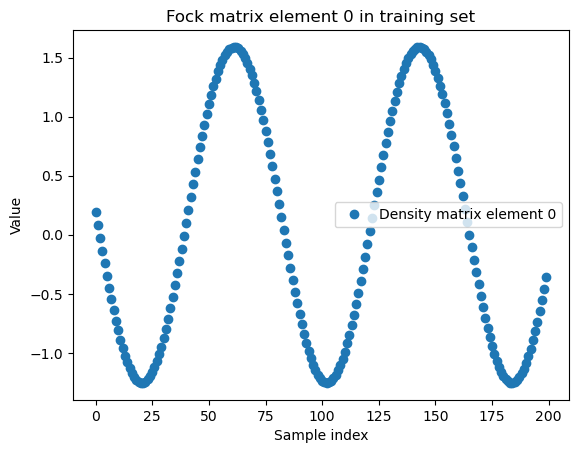

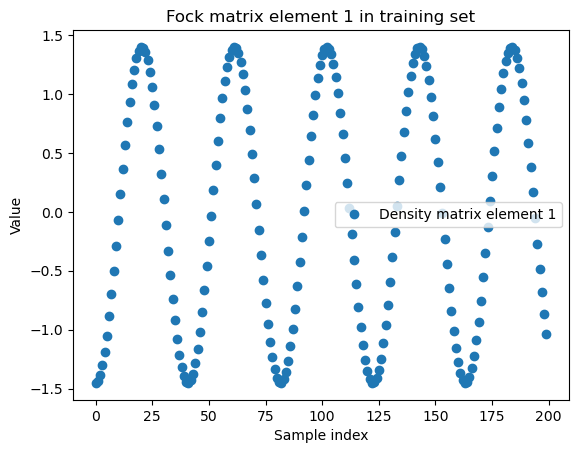

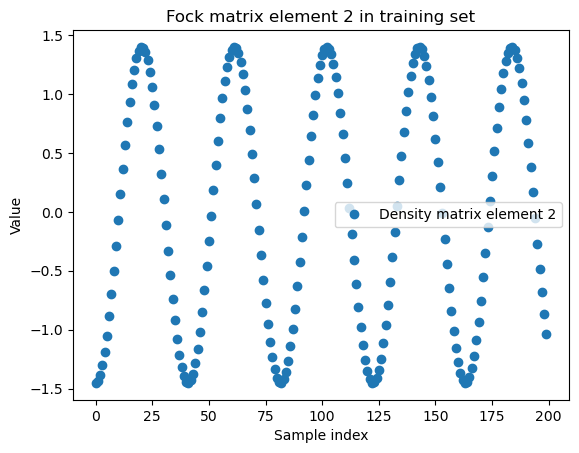

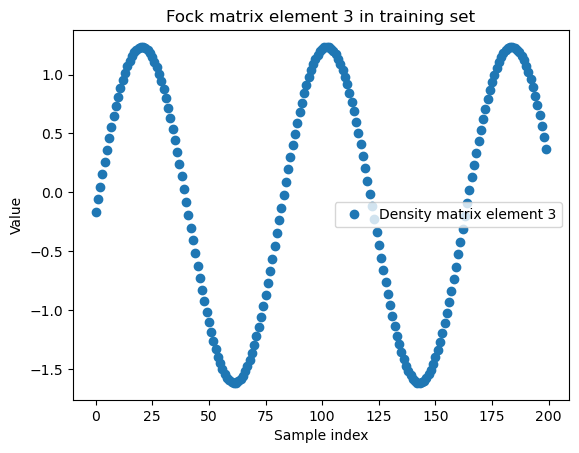

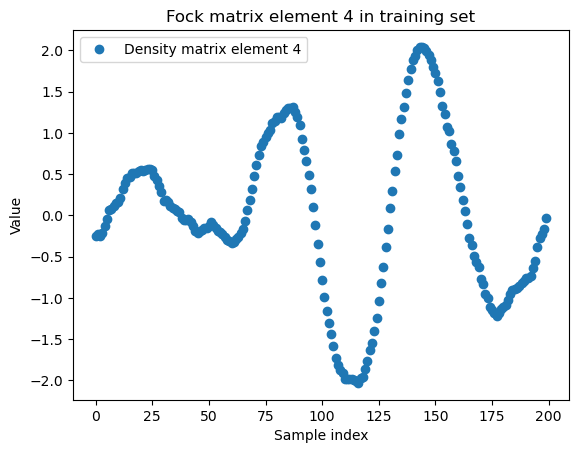

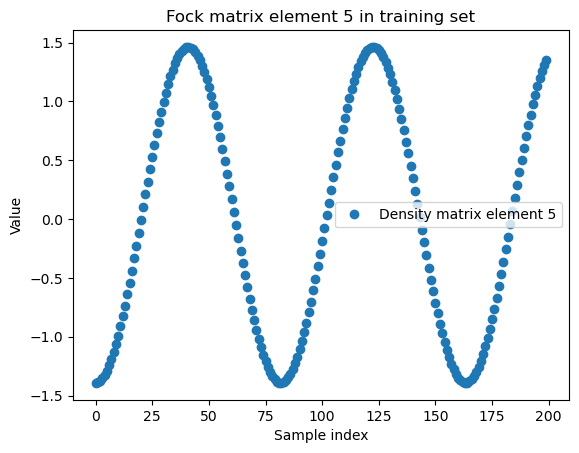

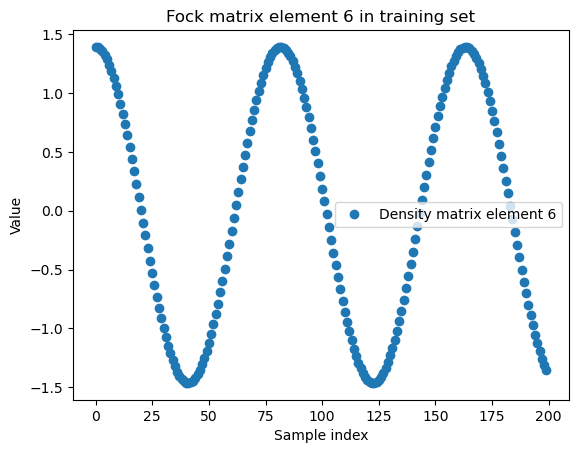

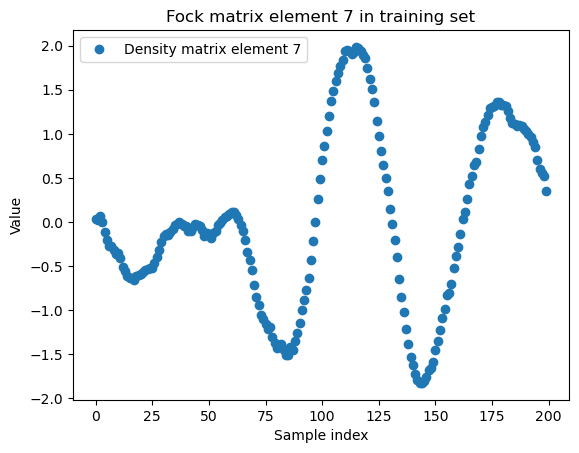

In [6]:
# PLOT elements of the first Fock matrix
import matplotlib.pyplot as plt

xvals = np.arange(0, trainsetdim, 1)
for i in range(8):
    yvals = X_train[:, i]
    plt.plot(xvals, yvals, 'o', label='Density matrix element {}'.format(i))
    plt.xlabel('Sample index')
    plt.ylabel('Value')
    plt.title('Fock matrix element {} in training set'.format(i))
    plt.legend()
    plt.show()

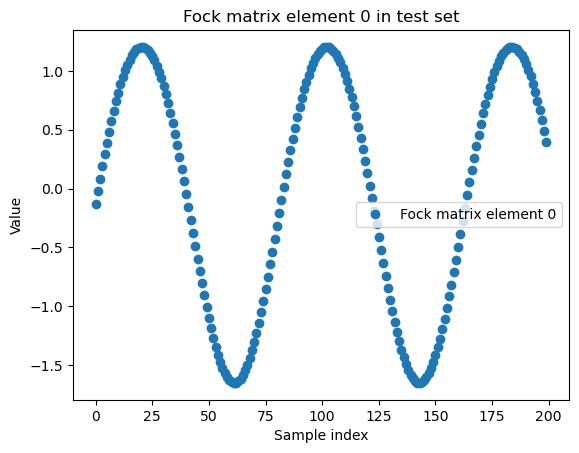

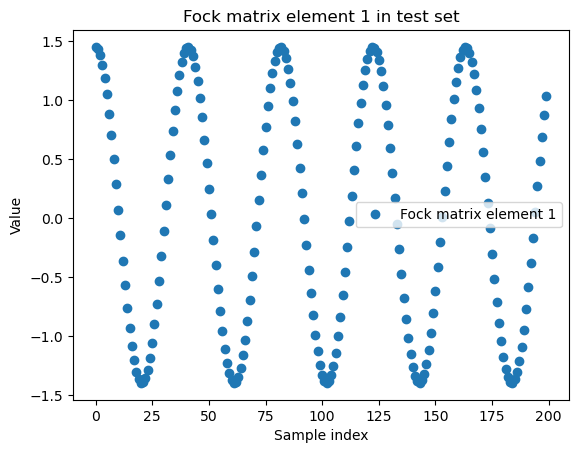

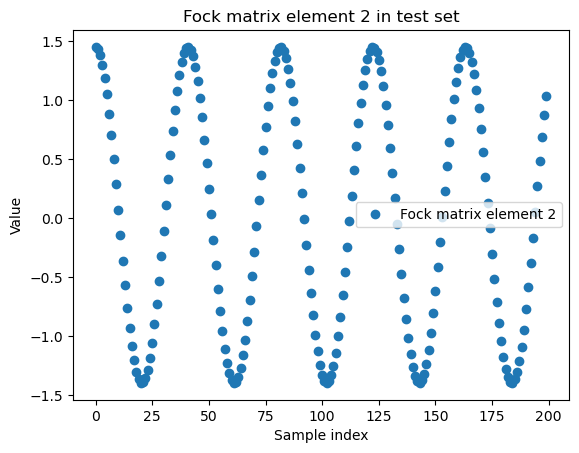

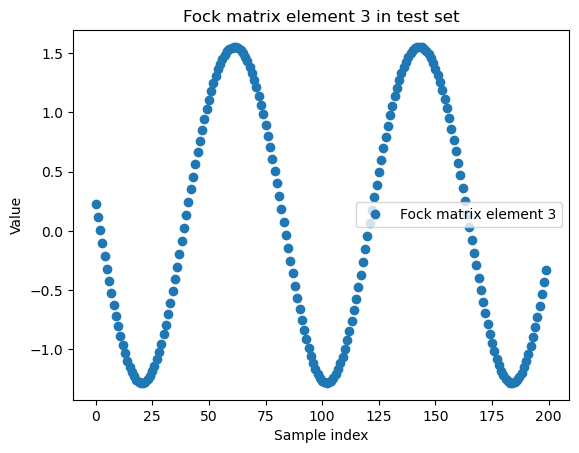

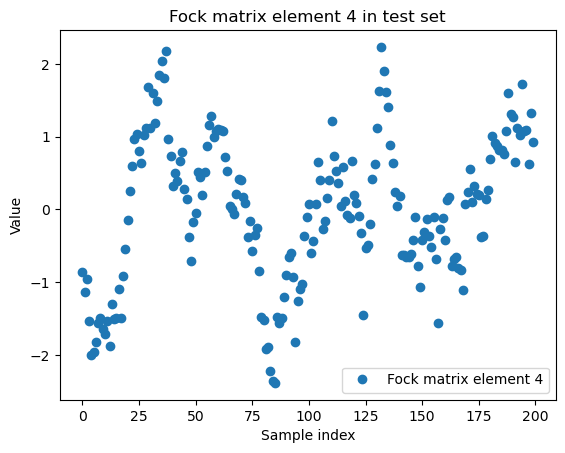

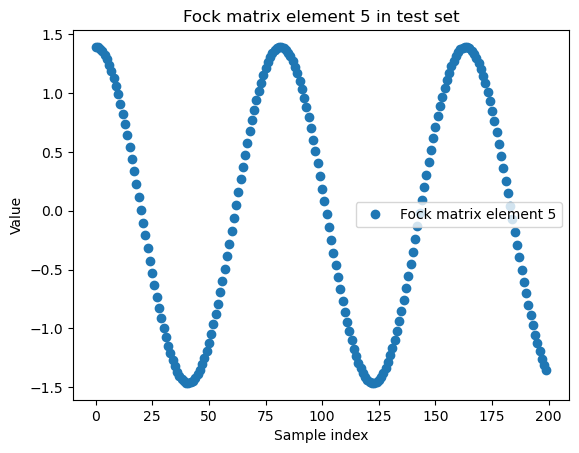

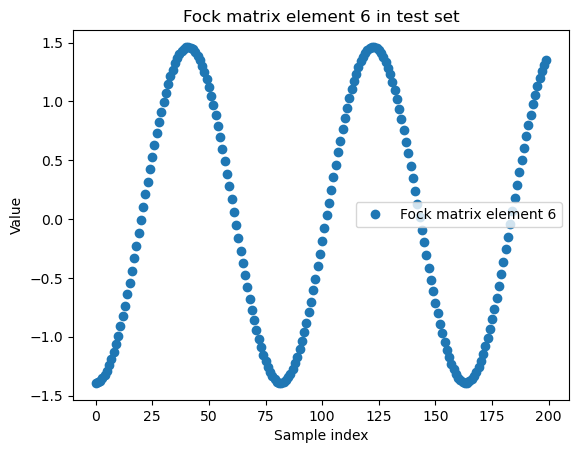

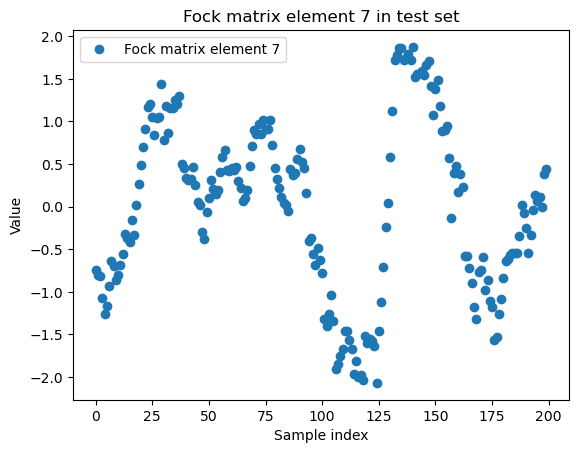

In [7]:
import matplotlib.pyplot as plt
xvals = np.arange(0, trainsetdim, 1)

for i in range(0,8):
    yvals = Y_train[:, i]
    plt.plot(xvals, yvals, 'o', label='Fock matrix element {}'.format(i))
    plt.xlabel('Sample index')
    plt.ylabel('Value')
    plt.title('Fock matrix element {} in test set'.format(i))
    plt.legend()
    plt.show()

2025-06-26 01:43:43.575591: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-26 01:43:43.713631: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-26 01:43:43.881625: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750895024.060439  111632 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750895024.073108  111632 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1750895024.177741  111632 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

Epoch 1/100


2025-06-26 01:43:49.452559: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 89ms/step - loss: 1.0069 - val_loss: 0.7558
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.9351 - val_loss: 0.7095
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.8501 - val_loss: 0.6686
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.7931 - val_loss: 0.6258
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.7209 - val_loss: 0.5842
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.6177 - val_loss: 0.5405
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.5548 - val_loss: 0.4973
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.4733 - val_loss: 0.4571
Epoch 9/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.4165 - val_loss: 0.4261
Epoch 10/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.3639 - val_loss: 0.4088
Epoch 11/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.3073 - val_loss: 0.3894
Epoch 12/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.2609 - val_loss: 0.3635
E

Model: "sequential"

...

 Total params: 16,418 (64.14 KB)

 Trainable params: 5,472 (21.38 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 10,946 (42.76 KB)

None


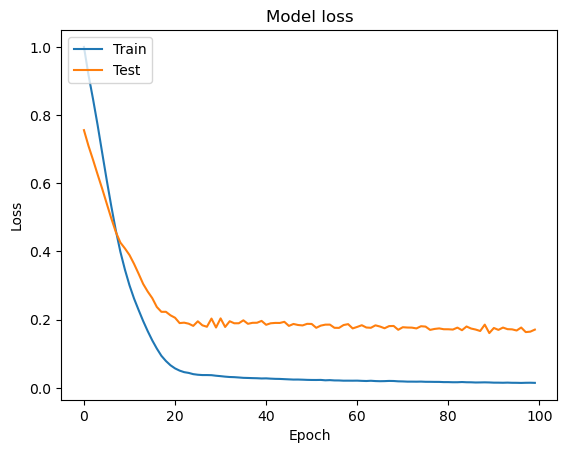

In [8]:
# build a NN using tensorflow
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    #layers.Dense(256, activation='relu'),
    layers.Dense(24, activation='relu'),
    layers.Dense(Y_train.shape[1], activation='linear')
])
model.compile(optimizer='adam', loss='mean_squared_error')
# Train the model
history = model.fit(X_train, Y_train, epochs=100,validation_split=0.2, batch_size=32)
# Save the model
model.save("tdexx_model.h5")
print(model.summary())


# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
Mean Absolute Percentage Error (MAPE): 0.08949427261190994
Mean Squared Error (MSE): 7.382593320852559e-07


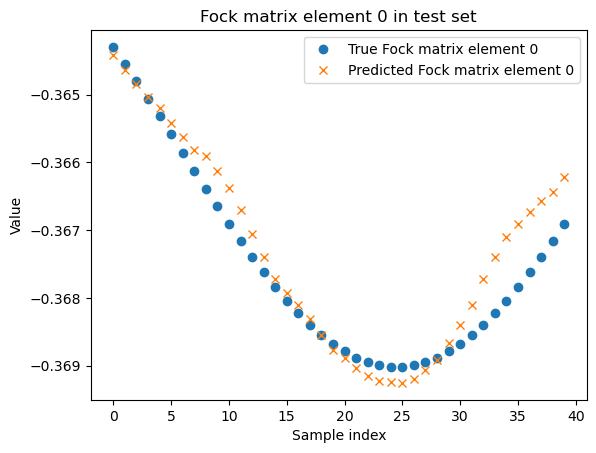

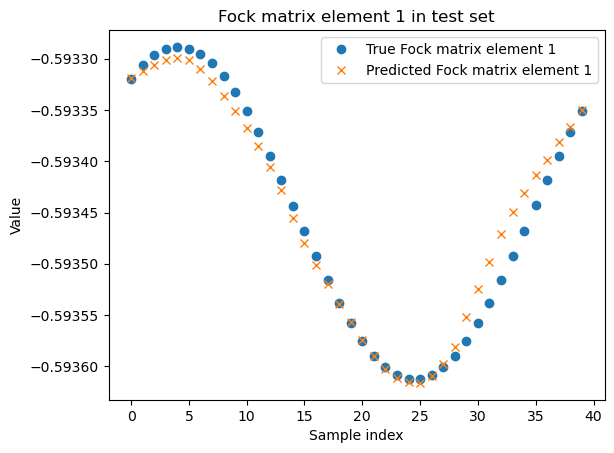

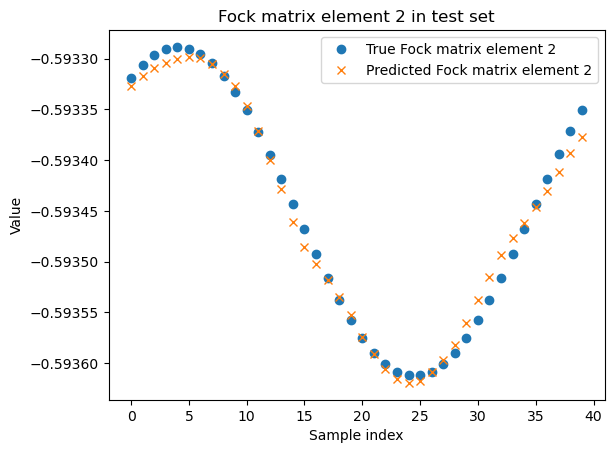

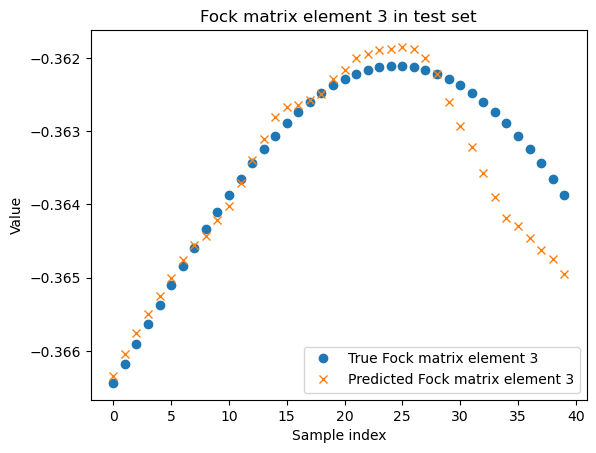

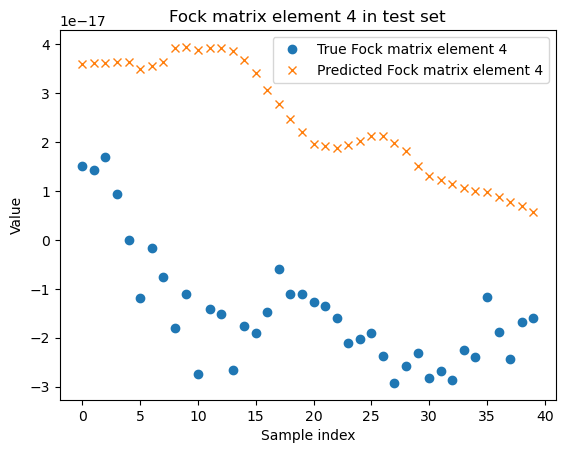

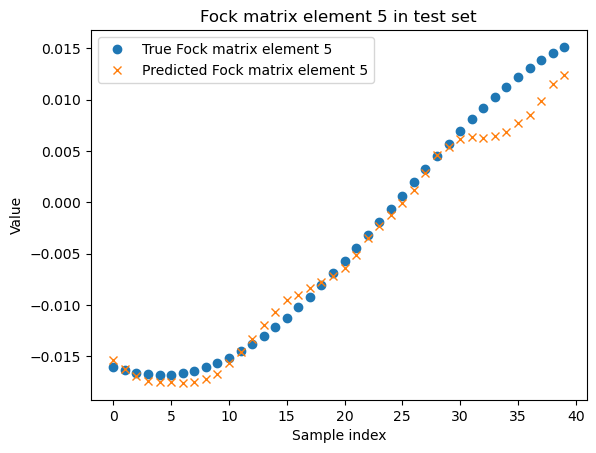

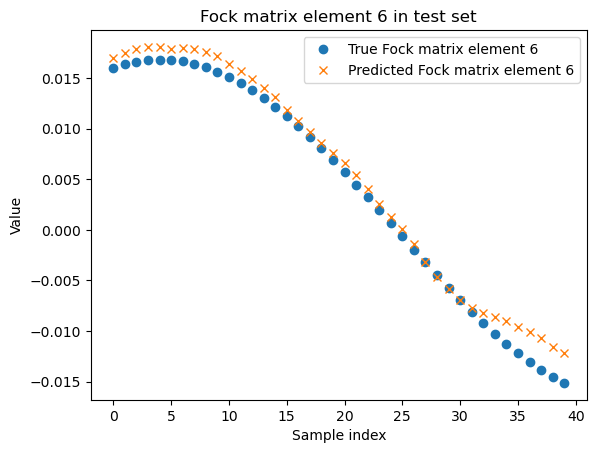

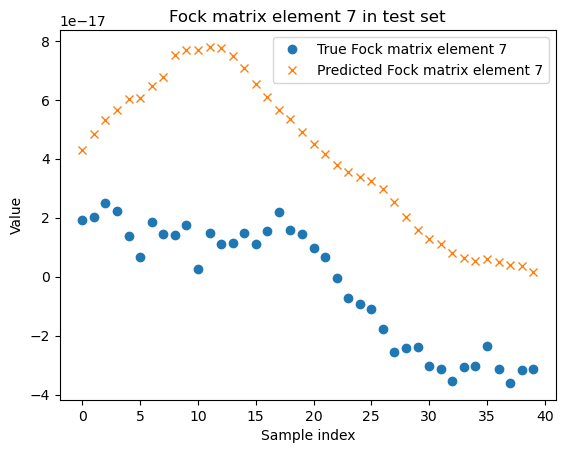

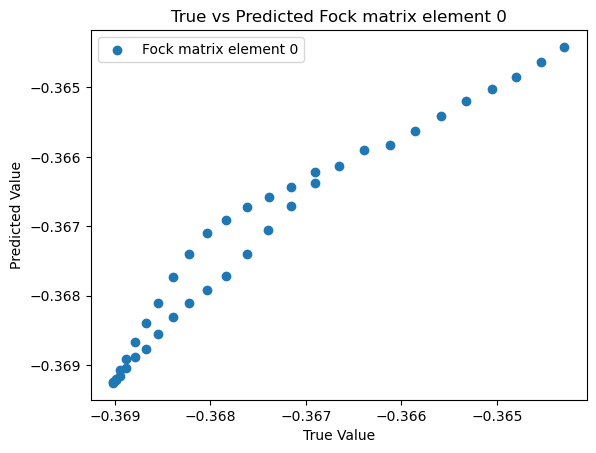

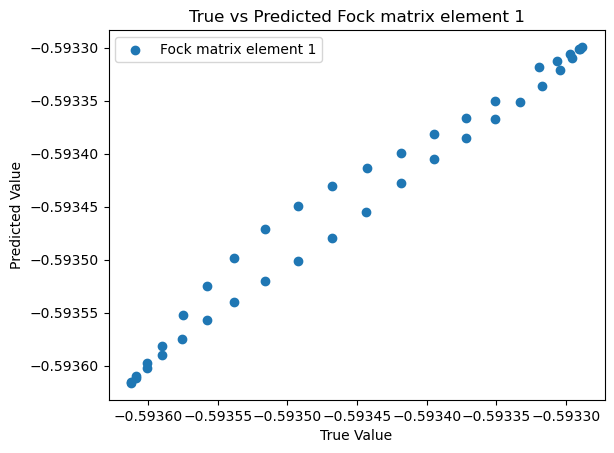

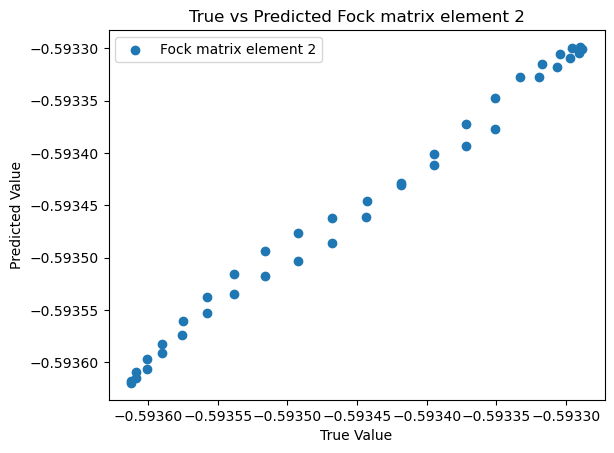

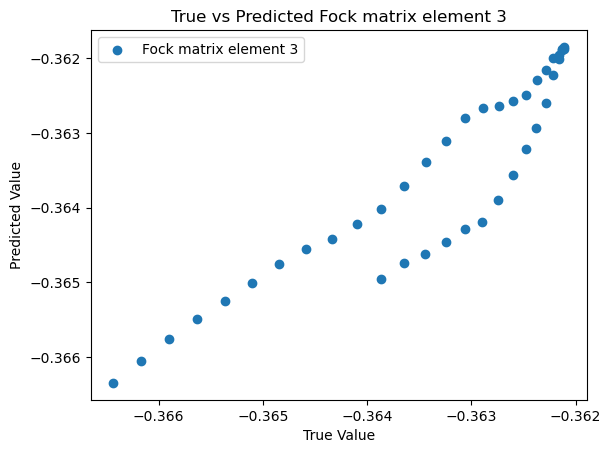

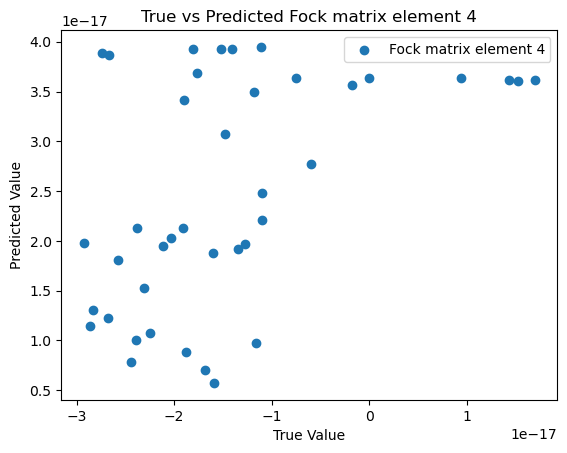

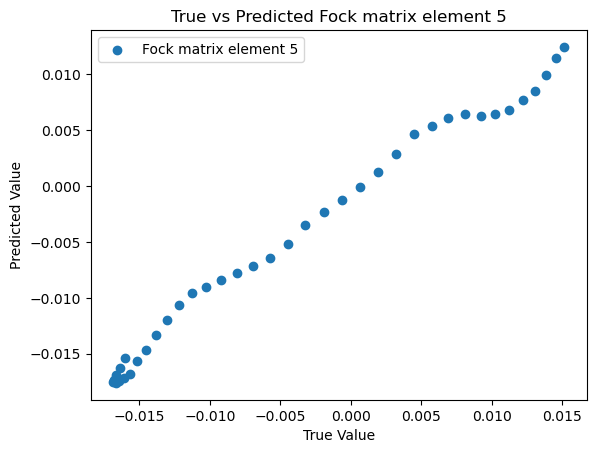

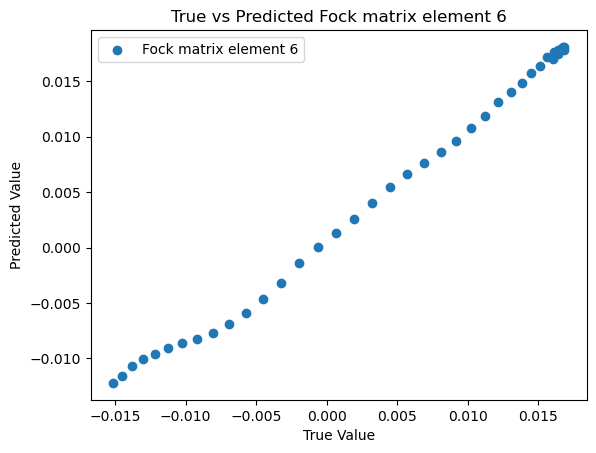

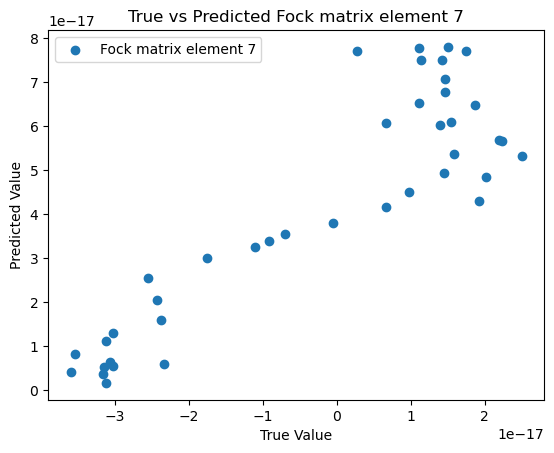

In [9]:
import sklearn
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
# Evaluate the model
Y_pred = model.predict(X_test)
Y_pred = scalerY.inverse_transform(Y_pred)  # Inverse transform to get original scale
Y_test = scalerY.inverse_transform(Y_test)  # Inverse transform to get original scale
mape = mean_absolute_percentage_error(Y_test, Y_pred)
mse = mean_squared_error(Y_test, Y_pred)
print("Mean Absolute Percentage Error (MAPE):", mape)
print("Mean Squared Error (MSE):", mse)

# plot testset results
xvals = np.arange(0, testsetdim, 1)
for i in range(8):
    yvals = Y_test[:, i]
    ypreds = Y_pred[:, i]
    plt.plot(xvals, yvals, 'o', label='True Fock matrix element {}'.format(i))
    plt.plot(xvals, ypreds, 'x', label='Predicted Fock matrix element {}'.format(i))
    plt.xlabel('Sample index')
    plt.ylabel('Value')
    plt.title('Fock matrix element {} in test set'.format(i))
    plt.legend()
    plt.show()

# scatter plot of true vs predicted values
for i in range(8):
    plt.scatter(Y_test[:, i], Y_pred[:, i], label='Fock matrix element {}'.format(i))
    plt.xlabel('True Value')
    plt.ylabel('Predicted Value')
    plt.title('True vs Predicted Fock matrix element {}'.format(i))
    plt.legend()
    plt.show()